In [1]:
from pathlib import Path
import hashlib
import sys
import zipfile
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import butter, sosfiltfilt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src' / 'obp_utils.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Launch Jupyter inside the repository.')
RAW = ROOT / 'data' / 'raw' / 'hitting'
RAW.mkdir(parents=True, exist_ok=True)
BASE = 'https://github.com/drivelineresearch/openbiomechanics/releases/download/dataset-v1/'
ANGLE_SHA256 = '98a405c5c4a27c1a599d3e30b39a3087180cc4d4bb69faf62204a1c06881be95'
METADATA_URL = ('https://raw.githubusercontent.com/drivelineresearch/openbiomechanics/'
                'dataset-v1/baseball_hitting/data/metadata.csv')

def data_files():
    angle_path = RAW / 'joint_angles.csv'
    if not angle_path.exists():
        archive = RAW / 'joint_angles.zip'
        if not archive.exists():
            urlretrieve(BASE + 'hitting_joint_angles.zip', archive)
        digest = hashlib.sha256(archive.read_bytes()).hexdigest()
        if digest != ANGLE_SHA256:
            raise ValueError(f'Joint-angle archive hash mismatch: {digest}')
        with zipfile.ZipFile(archive) as zf:
            matches = [n for n in zf.namelist() if Path(n).name == 'joint_angles.csv']
            if len(matches) != 1:
                raise ValueError('Expected exactly one joint_angles.csv in archive')
            with zf.open(matches[0]) as source, angle_path.open('wb') as target:
                import shutil
                shutil.copyfileobj(source, target)
    meta_path = RAW / 'metadata.csv'
    if not meta_path.exists():
        urlretrieve(METADATA_URL, meta_path)
    return angle_path, meta_path

angle_path, meta_path = data_files()
angles = pd.read_csv(angle_path, usecols=[
    'session_swing', 'time', 'pelvis_angle_z', 'torso_angle_z',
    'fp_10_time', 'fp_100_time', 'contact_time'], dtype={'session_swing': str})
metadata = pd.read_csv(meta_path, usecols=[
    'session_swing', 'user', 'session', 'hitter_side'],
    dtype={'session_swing': str, 'user': str, 'session': str})
if metadata.session_swing.duplicated().any() or angles.duplicated(['session_swing', 'time']).any():
    raise ValueError('Duplicate swing metadata or angle time keys')
swings = angles.merge(metadata, on='session_swing', validate='many_to_one')
print(f'{swings.session_swing.nunique():,} swings, {swings.user.nunique():,} athletes')


677 swings, 98 athletes


In [2]:
def onset_features(group, cutoff_hz=12, fraction=0.15, floor_dps=60, run_frames=3):
    g = group.sort_values('time')
    t = g.time.to_numpy(dtype=float)
    events = g[['fp_10_time', 'fp_100_time', 'contact_time']].iloc[0]
    ffc, plant, contact = events.to_numpy(dtype=float)
    if not np.isfinite([ffc, plant, contact]).all():
        return None, 'missing event'
    if not (t[0] <= ffc - 0.15 < ffc <= plant < contact <= t[-1]):
        return None, 'event outside sampled range or order'
    if not 0.08 <= contact - plant <= 0.20:
        return None, 'plant-to-contact outside 80–200 ms'
    if len(t) < 30 or not np.isfinite(t).all() or np.any(np.diff(t) <= 0):
        return None, 'invalid/short time signal'
    dt = np.median(np.diff(t))
    if not np.allclose(np.diff(t), dt, rtol=0.05, atol=1e-6):
        return None, 'irregular sampling'
    if cutoff_hz >= 0.5 / dt:
        return None, 'cutoff above Nyquist'
    search = np.flatnonzero((t >= ffc - 0.15) & (t <= contact))
    peak_window = np.flatnonzero((t >= plant) & (t <= contact))
    if len(search) < run_frames or len(peak_window) < 20:
        return None, 'too few event-window frames'
    result = dict(session_swing=str(g.session_swing.iloc[0]),
                  user=str(g.user.iloc[0]), session=str(g.session.iloc[0]),
                  hitter_side=g.hitter_side.iloc[0],
                  ffc_time=ffc, plant_time=plant, contact_time=contact)
    traces = {'time': t}
    for name in ('pelvis', 'torso'):
        angle = g[f'{name}_angle_z'].to_numpy(dtype=float)
        if not np.isfinite(angle).all():
            return None, 'missing angle sample'

        angle = np.rad2deg(np.unwrap(np.deg2rad(angle)))
        sos = butter(4, cutoff_hz, fs=1 / dt, output='sos')
        try:
            smooth = sosfiltfilt(sos, angle)
        except ValueError:
            return None, 'signal too short for filter'
        rate = np.gradient(smooth, t)
        peak_idx = peak_window[np.argmax(rate[peak_window])]
        peak = rate[peak_idx]
        threshold = max(floor_dps, fraction * peak)
        if peak <= threshold:
            return None, f'{name} has no forward peak above threshold'
        candidates = search[search <= peak_idx]
        mask = rate[candidates] >= threshold

        onset = next((int(candidates[i]) for i in range(len(candidates) - run_frames + 1)
                      if np.all(mask[i:i + run_frames])
                      and np.all(np.diff(candidates[i:i + run_frames]) == 1)), None)
        if onset is None:
            return None, f'{name} has no sustained onset'
        result[f'{name}_onset_time'] = t[onset]
        result[f'{name}_onset_frame'] = onset
        result[f'{name}_onset_ms_from_plant'] = 1000 * (t[onset] - plant)
        result[f'{name}_peak_dps'] = float(peak)
        traces[f'{name}_angle'] = smooth
        traces[f'{name}_rate'] = rate
    result['onset_lag_ms'] = 1000 * (result['torso_onset_time'] - result['pelvis_onset_time'])
    result['separation_window_ms'] = max(0., result['onset_lag_ms'])
    result['sequence'] = ('pelvis first' if result['onset_lag_ms'] > dt * 500
                          else 'torso first' if result['onset_lag_ms'] < -dt * 500
                          else 'same frame')

    traces['torso_minus_pelvis'] = traces['torso_angle'] - traces['pelvis_angle']
    return (result, traces), 'retained'

records, traces_by_swing, statuses = [], {}, []
for swing_id, group in swings.groupby('session_swing', sort=False):
    found, status = onset_features(group)
    statuses.append({'session_swing': swing_id, 'status': status})
    if found is not None:
        row, trace = found
        records.append(row)
        traces_by_swing[swing_id] = trace
results = pd.DataFrame(records)
display(pd.DataFrame(statuses).status.value_counts().rename('swings').to_frame())
if results.empty:
    raise ValueError('No swings retained; inspect event and signal exclusions above.')
display(results[['session_swing', 'hitter_side', 'pelvis_onset_ms_from_plant',
                 'torso_onset_ms_from_plant', 'onset_lag_ms', 'sequence']].head(10))


,swings
status,
retained,615
plant-to-contact outside 80–200 ms,27
missing event,27
event outside sampled range or order,8


,session_swing,hitter_side,pelvis_onset_ms_from_plant,torso_onset_ms_from_plant,onset_lag_ms,sequence
0,103_1,R,-80.5,-16.6,63.9,pelvis first
1,103_2,R,-58.3,-16.7,41.6,pelvis first
2,103_3,R,-66.7,-13.9,52.8,pelvis first
3,103_4,R,-69.4,-19.4,50.0,pelvis first
4,103_5,R,-75.0,-27.8,47.2,pelvis first
5,111_1,L,-100.0,-75.0,25.0,pelvis first
6,111_2,L,-100.0,-69.5,30.5,pelvis first
7,111_3,L,-105.5,-75.0,30.5,pelvis first
8,111_4,L,-77.8,-50.0,27.8,pelvis first
9,111_5,L,-108.3,-77.7,30.6,pelvis first


Retained: 615 swings from 93 athletes


,swings
sequence,
pelvis first,614
torso first,1


,count,median,mean,std
sequence,,,,
pelvis first,614,50.0,50.5,15.2
torso first,1,-2.8,-2.8,NaN


Median athlete-level onset lag: 50.0 ms


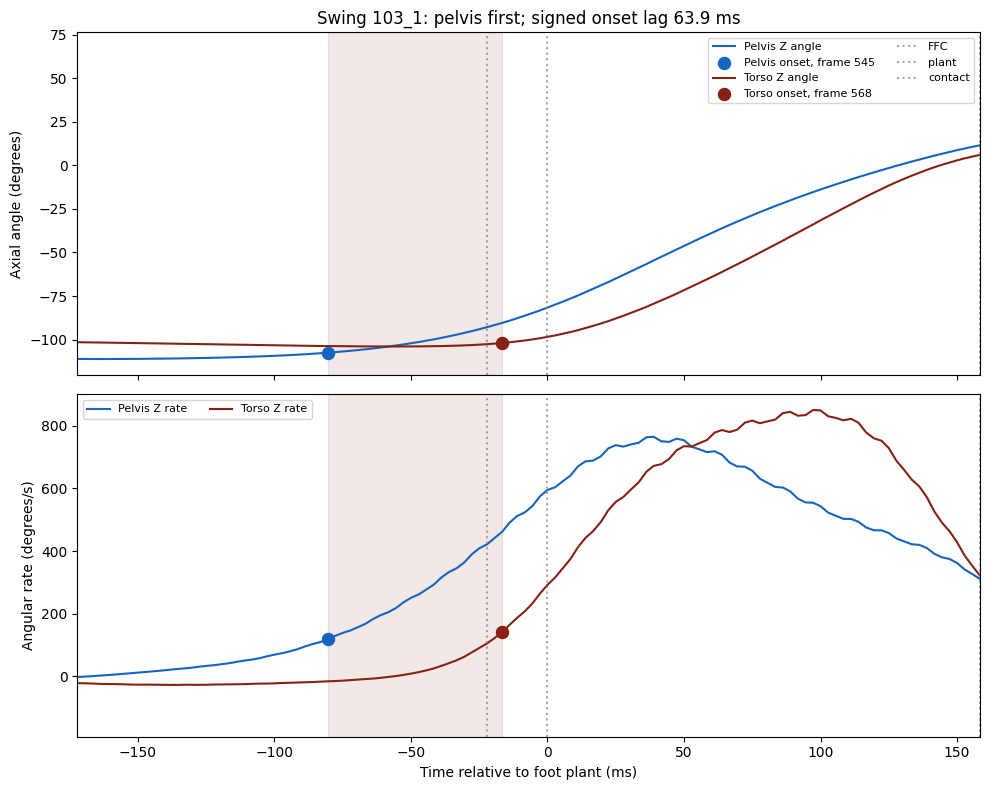

,event,time_s,nearest_zero_based_frame
0,FFC,1.5722,566
1,plant,1.5944,574
2,pelvis onset,1.5139,545
3,torso onset,1.5778,568
4,contact,1.7528,631


In [3]:
print(f'Retained: {len(results)} swings from {results.user.nunique()} athletes')
display(results.sequence.value_counts().rename('swings').to_frame())
display(results.groupby('sequence').onset_lag_ms.agg(['count', 'median', 'mean', 'std']).round(1))

athlete_medians = results.groupby('user').onset_lag_ms.median()
print(f'Median athlete-level onset lag: {athlete_medians.median():.1f} ms')

SELECTED_SWING = None
selected = str(SELECTED_SWING) if SELECTED_SWING is not None else str(results.session_swing.iloc[0])
if selected not in traces_by_swing:
    raise KeyError(f'{selected} was not retained')
row = results.set_index('session_swing').loc[selected]
trace = traces_by_swing[selected]
t = trace['time']
ms = 1000 * (t - row.plant_time)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for name, color in [('pelvis', '#1565C0'), ('torso', '#872113')]:
    axes[0].plot(ms, trace[f'{name}_angle'], label=f'{name.title()} Z angle', color=color)
    idx = int(row[f'{name}_onset_frame'])
    axes[0].scatter(ms[idx], trace[f'{name}_angle'][idx], s=75, color=color, zorder=4,
                    label=f'{name.title()} onset, frame {idx}')
    axes[1].plot(ms, trace[f'{name}_rate'], label=f'{name.title()} Z rate', color=color)
    axes[1].scatter(ms[idx], trace[f'{name}_rate'][idx], s=75, color=color, zorder=4)
for ax in axes:
    for event, label in [('ffc_time', 'FFC'), ('plant_time', 'plant'), ('contact_time', 'contact')]:
        ax.axvline(1000 * (row[event] - row.plant_time), color='gray', linestyle=':',
                   alpha=0.7, label=label if ax is axes[0] else None)
    ax.axvspan(min(row.pelvis_onset_ms_from_plant, row.torso_onset_ms_from_plant),
               max(row.pelvis_onset_ms_from_plant, row.torso_onset_ms_from_plant),
               alpha=0.10, color='#872113')
    ax.legend(loc='best', ncol=2, fontsize=8)
axes[0].set_ylabel('Axial angle (degrees)')
axes[1].set_ylabel('Angular rate (degrees/s)')
axes[1].set_xlabel('Time relative to foot plant (ms)')
axes[0].set_title(f'Swing {selected}: {row.sequence}; signed onset lag {row.onset_lag_ms:.1f} ms')
axes[0].set_xlim(1000 * (row.ffc_time - 0.15 - row.plant_time),
                 1000 * (row.contact_time - row.plant_time))
plt.tight_layout()
plt.show()
display(pd.DataFrame([
    {'event': event, 'time_s': row[key], 'nearest_zero_based_frame': int(np.argmin(abs(t - row[key])))}
    for event, key in [('FFC', 'ffc_time'), ('plant', 'plant_time'),
                       ('pelvis onset', 'pelvis_onset_time'),
                       ('torso onset', 'torso_onset_time'), ('contact', 'contact_time')]
]))


In [4]:
sensitivity = []
for cutoff in (8, 12, 16):
    for floor in (40, 60, 80):
        alt = []
        for _, group in swings.groupby('session_swing', sort=False):
            found, _ = onset_features(group, cutoff_hz=cutoff, floor_dps=floor)
            if found is not None:
                alt.append(found[0])
        alternate = pd.DataFrame(alt)
        sensitivity.append({
            'cutoff_hz': cutoff, 'floor_dps': floor, 'retained_swings': len(alt),
            'pelvis_first_pct': 100 * alternate.sequence.eq('pelvis first').mean() if len(alt) else np.nan,
            'median_lag_ms': alternate.onset_lag_ms.median() if len(alt) else np.nan,
        })
display(pd.DataFrame(sensitivity).round(1))


,cutoff_hz,floor_dps,retained_swings,pelvis_first_pct,median_lag_ms
0,8,40,615,100.0,52.8
1,8,60,615,100.0,52.8
2,8,80,615,100.0,52.8
3,12,40,615,99.8,50.0
4,12,60,615,99.8,50.0
5,12,80,615,99.8,50.0
6,16,40,615,99.7,50.0
7,16,60,615,99.7,50.0
8,16,80,615,99.7,50.0
